In [1]:
!pip3 install -U ucimlrepo 

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)


                            mean        std         25%        50%       75%  \
fixed_acidity           6.854788   0.843868    6.300000    6.80000    7.3000   
volatile_acidity        0.278241   0.100795    0.210000    0.26000    0.3200   
citric_acid             0.334192   0.121020    0.270000    0.32000    0.3900   
residual_sugar          6.391415   5.072058    1.700000    5.20000    9.9000   
chlorides               0.045772   0.021848    0.036000    0.04300    0.0500   
free_sulfur_dioxide    35.308085  17.007137   23.000000   34.00000   46.0000   
total_sulfur_dioxide  138.360657  42.498065  108.000000  134.00000  167.0000   
density                 0.994027   0.002991    0.991723    0.99374    0.9961   
pH                      3.188267   0.151001    3.090000    3.18000    3.2800   
sulphates               0.489847   0.114126    0.410000    0.47000    0.5500   
alcohol                10.514267   1.230621    9.500000   10.40000   11.4000   
quality                 5.877909   0.885

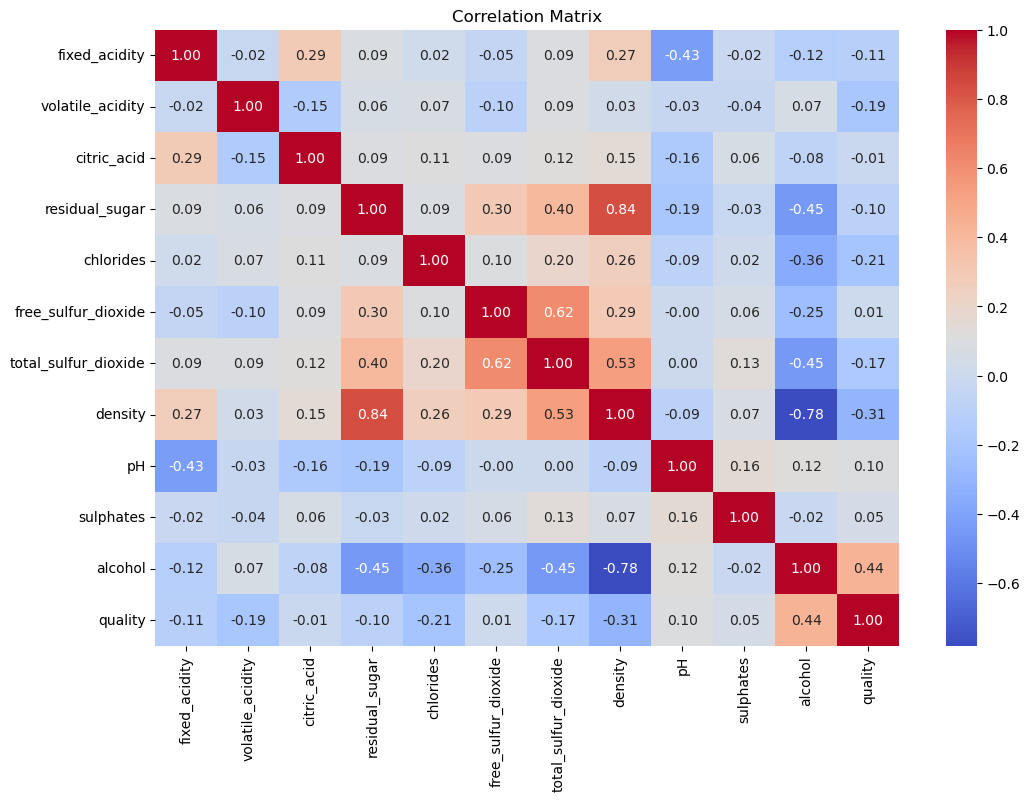

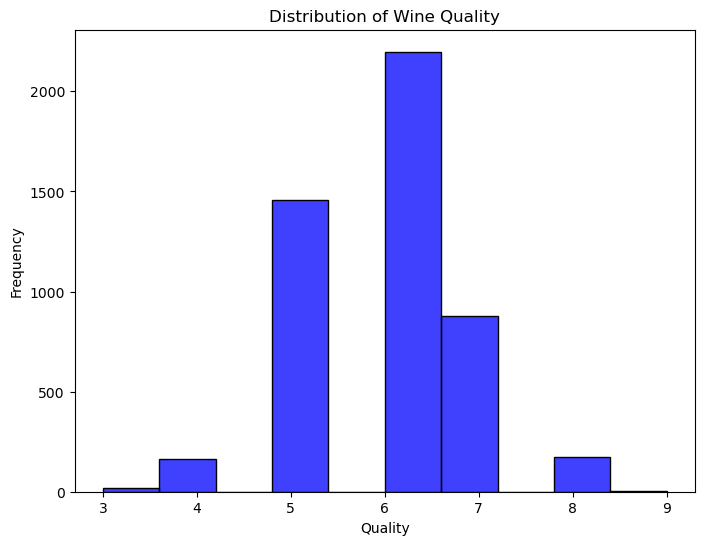

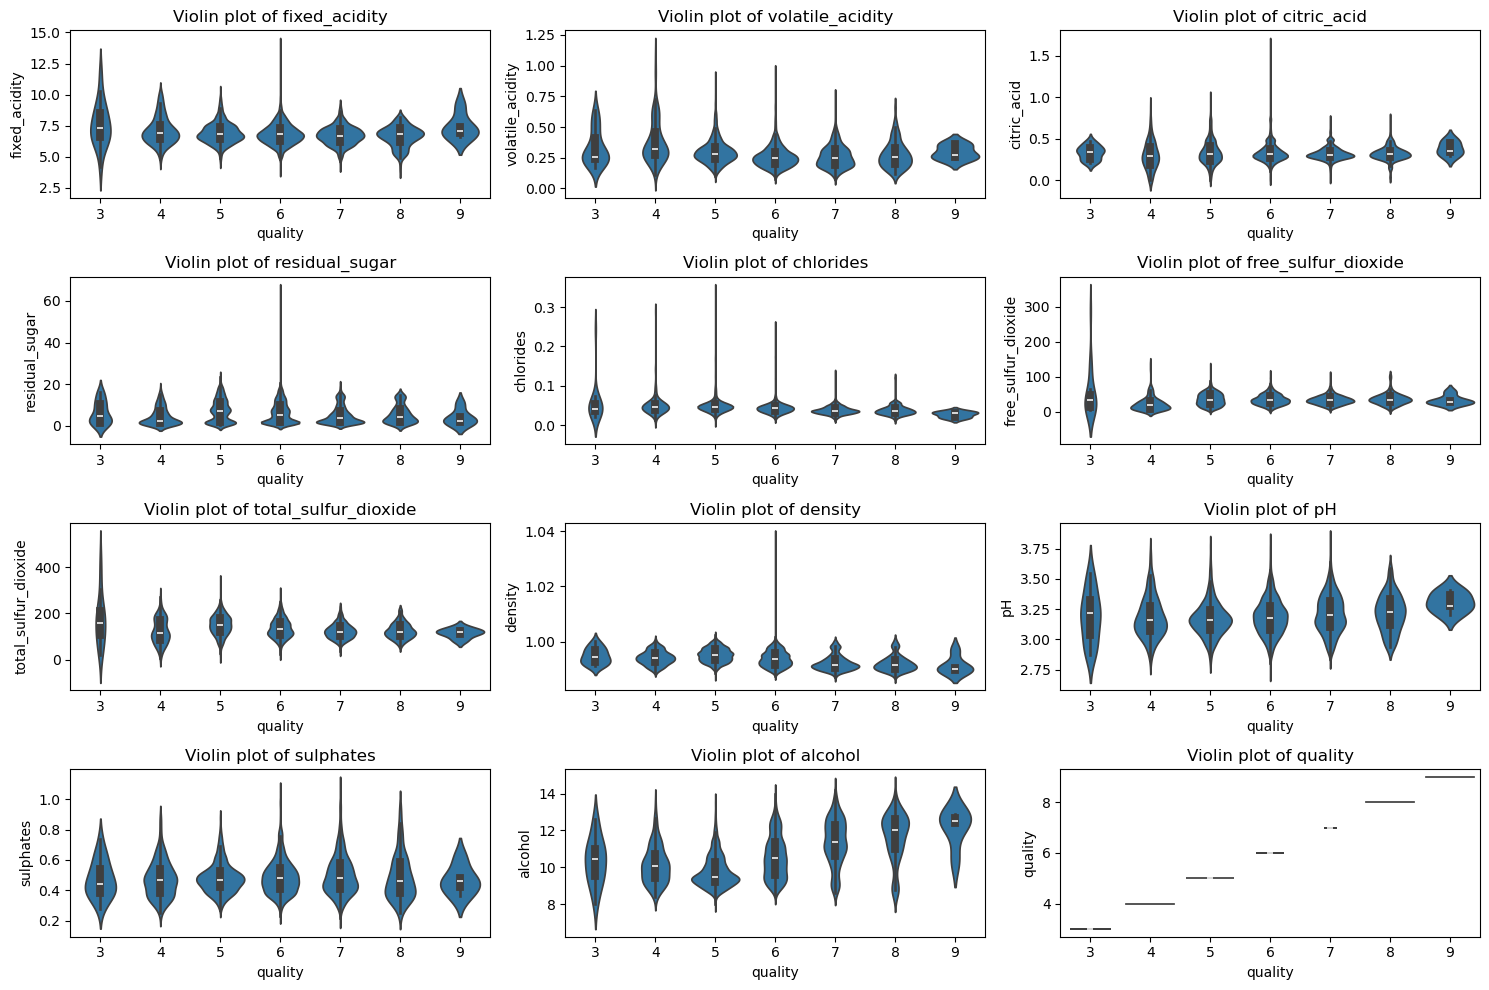

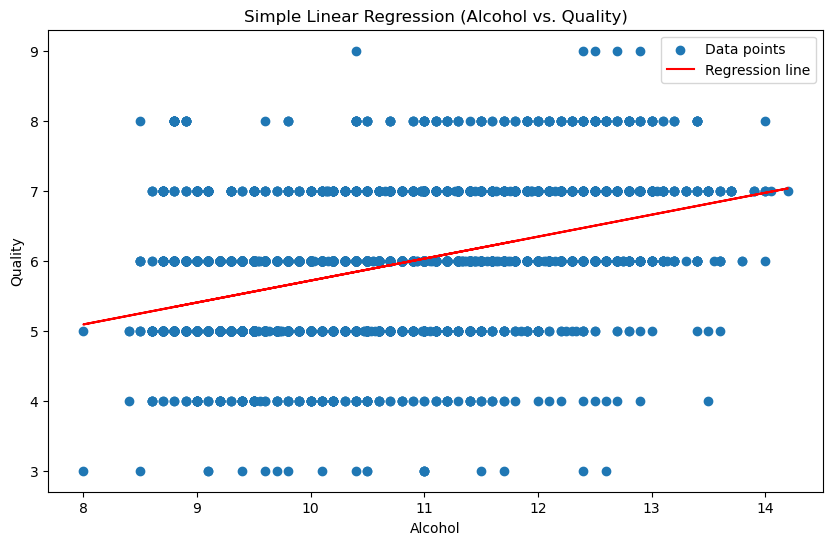

Intercept: 2.5820093991606585
Coefficient: 0.313469301913323
RMSE: 0.7971284628752668
R²: 0.18972533274950443
Intercept: -36.498611308344834
Coefficients: [-2.07211594  0.39889282 38.9918867 ]
RMSE: 0.7684872688163131
R²: 0.24690635620080092


In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
import matplotlib.pyplot as plt


# Fetch the dataset
wine_quality = fetch_ucirepo(id=186)
wine_data = wine_quality.data.original
# print(wine_data)

# Remove red wine data
substring = 'red'
filter = wine_data['color'].str.contains(substring)
white_wine_data = wine_data[~filter]

# print(white_wine_data)

# 1. Descriptive statistics
desc_stats = white_wine_data.describe().T

# Show the table
'''
print(desc_stats['mean'])
print(desc_stats['std'])
print(desc_stats[['25%','50%','75%']])
print(desc_stats['max'])
'''
print(desc_stats[['mean','std','25%','50%','75%','max']])
# 2. Correlation matrix
correlation_matrix = white_wine_data.loc[:, white_wine_data.columns != 'color'].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# 3. Histogram of quality
plt.figure(figsize=(8, 6))
sns.histplot(white_wine_data['quality'], kde=False, bins=10, color='blue')
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.show()

# 4. Violin plots for all features
plt.figure(figsize=(15, 10))
for i, column in enumerate(white_wine_data.columns[:-1], 1):
    plt.subplot(4, 3, i)
    sns.violinplot(x='quality', y=column, data=white_wine_data)
    plt.title(f'Violin plot of {column}')
plt.tight_layout()
plt.show()

# 5. Simple Linear Regression (alcohol vs. quality)
X_alcohol = white_wine_data[['alcohol']].values
y = white_wine_data['quality'].values

# Train model
model_simple = LinearRegression()
model_simple.fit(X_alcohol, y)

# Predictions
y_pred_simple = model_simple.predict(X_alcohol)

# Regression metrics
intercept_simple = model_simple.intercept_
coef_simple = model_simple.coef_[0]
rmse_simple = mean_squared_error(y, y_pred_simple, squared=False)
r2_simple = r2_score(y, y_pred_simple)

# Plot regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_alcohol, y, label='Data points')
plt.plot(X_alcohol, y_pred_simple, color='red', label='Regression line')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Simple Linear Regression (Alcohol vs. Quality)')
plt.legend()
plt.show()

# Print metrics
print(f"Intercept: {intercept_simple}")
print(f"Coefficient: {coef_simple}")
print(f"RMSE: {rmse_simple}")
print(f"R²: {r2_simple}")

# 6. Multiple Linear Regression (volatile_acidity, alcohol, density vs. quality)
X_multiple = white_wine_data[['volatile_acidity', 'alcohol', 'density']].values
model_multiple = LinearRegression()
model_multiple.fit(X_multiple, y)

# Predictions
y_pred_multiple = model_multiple.predict(X_multiple)

# Regression metrics
intercept_multiple = model_multiple.intercept_
coefs_multiple = model_multiple.coef_
rmse_multiple = mean_squared_error(y, y_pred_multiple, squared=False)
r2_multiple = r2_score(y, y_pred_multiple)

# Print metrics
print(f"Intercept: {intercept_multiple}")
print(f"Coefficients: {coefs_multiple}")
print(f"RMSE: {rmse_multiple}")
print(f"R²: {r2_multiple}")
